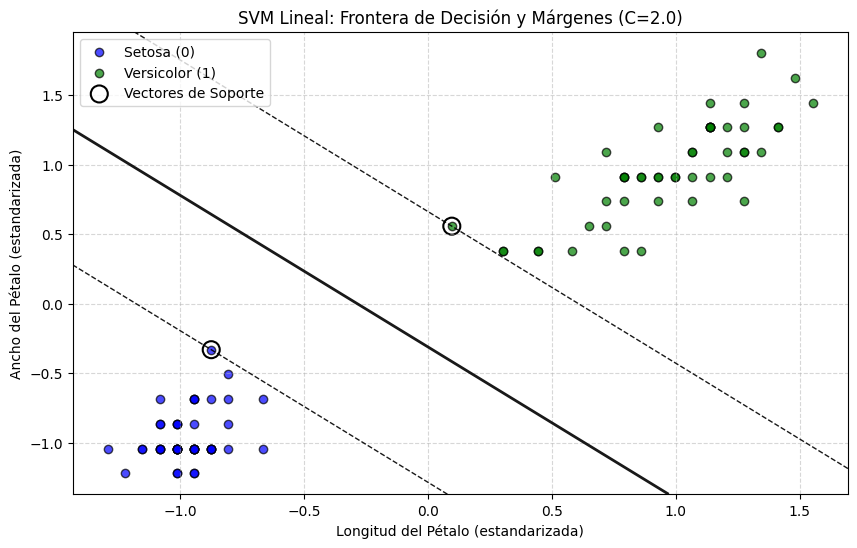

Número de vectores de soporte totales: 2
Vectores de soporte por clase (Setosa, Versicolor): [1 1]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Carga y Preparación del Dataset
# ==========================================
# Cargamos el dataset Iris directamente desde sklearn
iris = datasets.load_iris()

# Para visualizar fácilmente en 2D, seleccionamos solo 2 características:
# - Longitud del pétalo (columna 2)
# - Ancho del pétalo (columna 3)
X = iris.data[:, [2, 3]]
y = iris.target

# SVM Funciona mejor como clasificador binario para visualización directa.
# Filtramos para quedarnos solo con dos clases: Setosa (0) y Versicolor (1).
# Esto hace que el problema sea linealmente separable.
set_vers_mask = (y == 0) | (y == 1)
X = X[set_vers_mask]
y = y[set_vers_mask]

# Es CRÍTICO escalar los datos para SVM, ya que depende de distancias.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. Entrenamiento del Modelo SVM Lineal
# ==========================================
# Usamos el kernel 'linear'.
# El parámetro C controla la dureza del margen. C alto = margen duro (menos violaciones).
C_value = 2.0
svm_model = SVC(kernel='linear', C=C_value)
svm_model.fit(X_scaled, y)

# ==========================================
# 3. Función de Visualización
# ==========================================
def plot_svc_decision_boundary(svm_clf, X, y):
    """
    Visualiza la frontera de decisión, los márgenes y los vectores de soporte
    de un modelo SVM lineal en 2D.
    """
    plt.figure(figsize=(10, 6))

    # Graficar los puntos de datos
    # Clase 0 (Setosa) en azul, Clase 1 (Versicolor) en verde
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Setosa (0)', alpha=0.7, edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='green', label='Versicolor (1)', alpha=0.7, edgecolors='k')

    # Obtener los límites del gráfico actual
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Crear una malla (grid) para evaluar el modelo
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Calcular la función de decisión para cada punto de la malla
    # La frontera de decisión es donde decision_function == 0
    # Los márgenes son donde decision_function == 1 o -1
    Z = svm_clf.decision_function(xy).reshape(XX.shape)

    # Graficar la frontera de decisión y los márgenes usando contornos
    # levels=[0] es la línea continua (hiperplano)
    # levels=[-1, 1] son las líneas discontinuas (márgenes)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.9,
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

    # Resaltar los Vectores de Soporte (los puntos que tocan el margen)
    support_vectors = svm_clf.support_vectors_
    ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150,
               linewidth=1.5, facecolors='none', edgecolors='k', label='Vectores de Soporte')

    # Etiquetas y Título
    plt.xlabel('Longitud del Pétalo (estandarizada)')
    plt.ylabel('Ancho del Pétalo (estandarizada)')
    plt.title(f'SVM Lineal: Frontera de Decisión y Márgenes (C={C_value})')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# ==========================================
# 4. Ejecutar la Visualización
# ==========================================
plot_svc_decision_boundary(svm_model, X_scaled, y)

# Imprimir información útil
print(f"Número de vectores de soporte totales: {svm_model.support_.size}")
print(f"Vectores de soporte por clase (Setosa, Versicolor): {svm_model.n_support_}")